In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

In [2]:
def neighbor_count_wrap(grid: np.ndarray) -> np.ndarray:
    """8-neighbor count with wrap-around (toroidal)."""
    return (
        np.roll(np.roll(grid,  1, 0),  1, 1) +
        np.roll(grid,  1, 0) +
        np.roll(np.roll(grid,  1, 0), -1, 1) +
        np.roll(grid,  1, 1) +
        np.roll(grid, -1, 1) +
        np.roll(np.roll(grid, -1, 0),  1, 1) +
        np.roll(grid, -1, 0) +
        np.roll(np.roll(grid, -1, 0), -1, 1)
    )

def neighbor_count_nowrap(grid: np.ndarray) -> np.ndarray:
    """8-neighbor count with dead boundary (no wrap)."""
    p = np.pad(grid, 1, mode="constant")
    return (
        p[0:-2, 0:-2] + p[0:-2, 1:-1] + p[0:-2, 2:] +
        p[1:-1, 0:-2]                 + p[1:-1, 2:] +
        p[2:  , 0:-2] + p[2:  , 1:-1] + p[2:  , 2:]
    )

def step(grid: np.ndarray, *, wrap: bool = True) -> np.ndarray:
    """
    Compute one Game of Life step.
    grid must be 2D array of 0/1 (uint8 recommended).
    """
    n = neighbor_count_wrap(grid) if wrap else neighbor_count_nowrap(grid)

    survive = (grid == 1) & ((n == 2) | (n == 3))
    born    = (grid == 0) & (n == 3)
    return (survive | born).astype(np.uint8)

In [3]:
def place_pattern(grid: np.ndarray, pattern: np.ndarray, top: int, left: int) -> None:
    """Place a 0/1 pattern into grid at (top, left)."""
    h, w = pattern.shape
    grid[top:top+h, left:left+w] = pattern

GLIDER = np.array([
    [0,1,0],
    [0,0,1],
    [1,1,1],
], dtype=np.uint8)

BLINKER = np.array([[1,1,1]], dtype=np.uint8)

TOAD = np.array([
    [0,1,1,1],
    [1,1,1,0],
], dtype=np.uint8)

BLOCK = np.array([
    [1,1],
    [1,1],
], dtype=np.uint8)  # still life (won't change)

In [4]:
H, W = 60, 100
grid = np.zeros((H, W), dtype=np.uint8)

place_pattern(grid, GLIDER, 5, 5)
place_pattern(grid, BLINKER, 25, 40)
place_pattern(grid, TOAD, 40, 70)

# Quick sanity check: should be > 0
g2 = step(grid, wrap=False)
print("changed cells:", int(np.sum(g2 != grid)))

changed cells: 16


In [5]:
wrap_edges = False  # toggle True/False

fig, ax = plt.subplots(figsize=(7, 5))
img = ax.imshow(grid, interpolation="nearest", vmin=0, vmax=1)
ax.set_title("Conway's Game of Life")
ax.set_axis_off()

def update(_):
    global grid
    grid = step(grid, wrap=wrap_edges)
    img.set_data(grid)
    return (img,)

anim = animation.FuncAnimation(fig, update, frames=300, interval=60, blit=False)
plt.close(fig)  # avoids a static duplicate plot in output
display(HTML(anim.to_jshtml()))

In [6]:
def run_life(
    init_grid: np.ndarray,
    steps: int,
    *,
    wrap: bool = True,
    record_every: int = 1
):
    """
    Run Life for `steps` starting from `init_grid`.
    Returns: (snapshots, metrics)
      - snapshots: array of grids taken every `record_every` steps
      - metrics: dict with live, births, deaths (each length=steps)
    """
    grid = init_grid.copy().astype(np.uint8)

    live = np.zeros(steps, dtype=int)
    births = np.zeros(steps, dtype=int)
    deaths = np.zeros(steps, dtype=int)
    snapshots = []

    neighbor_count = neighbor_count_wrap if wrap else neighbor_count_nowrap

    for t in range(steps):
        n = neighbor_count(grid)

        survive = (grid == 1) & ((n == 2) | (n == 3))
        born    = (grid == 0) & (n == 3)
        next_grid = (survive | born).astype(np.uint8)

        live[t] = int(next_grid.sum())
        births[t] = int(born.sum())
        deaths[t] = int(((grid == 1) & (next_grid == 0)).sum())

        grid = next_grid

        if (t % record_every) == 0:
            snapshots.append(grid.copy())

    metrics = {"live": live, "births": births, "deaths": deaths}
    return np.array(snapshots, dtype=np.uint8), metrics

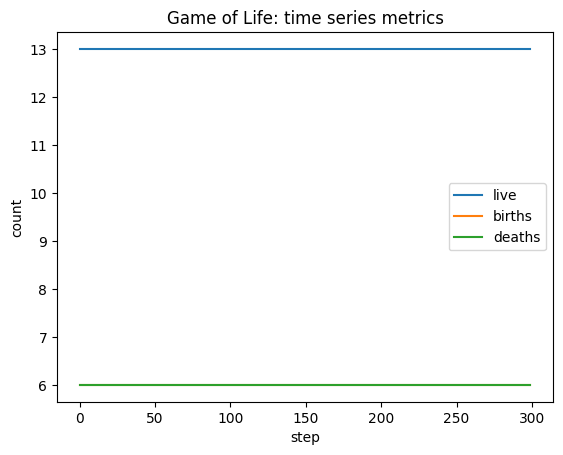

In [7]:
# Example: run the seeded world above
snaps, metrics = run_life(grid, steps=300, wrap=False, record_every=10)

plt.figure()
plt.plot(metrics["live"], label="live")
plt.plot(metrics["births"], label="births")
plt.plot(metrics["deaths"], label="deaths")
plt.legend()
plt.xlabel("step")
plt.ylabel("count")
plt.title("Game of Life: time series metrics")
plt.show()

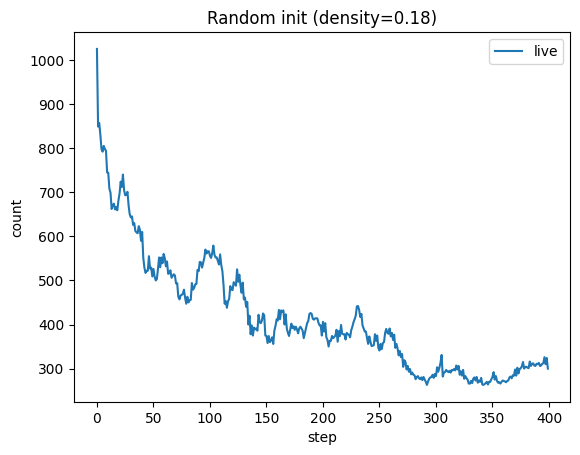

In [8]:
rng = np.random.default_rng(0)
density = 0.18

init = (rng.random((H, W)) < density).astype(np.uint8)
snaps_r, metrics_r = run_life(init, steps=400, wrap=False, record_every=20)

plt.figure()
plt.plot(metrics_r["live"], label="live")
plt.legend()
plt.xlabel("step")
plt.ylabel("count")
plt.title(f"Random init (density={density})")
plt.show()